
# Glucose Level Prediction Project

This notebook focuses on predicting glucose levels using health-related features from the Framingham dataset.
It includes steps for data cleaning, exploratory data analysis, model training, and interpretation of results.



## What To Do

1. Import and explore the `framingham.csv` dataset.
2. Clean the data (handle nulls, correct formats, etc.).
3. Visualize the distribution of glucose and related health indicators.
4. Perform feature selection and engineering.
5. Train ML models (e.g., Logistic Regression, Decision Tree, Random Forest).
6. Evaluate models using classification metrics.
7. Predict glucose levels and draw insights.
8. Visualize the model’s important features and performance.


# Import and explore the Dataseet

---



In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [62]:
dataset = pd.read_csv("framingham[1].csv")
dataset.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# Clean the data (handle nulls, correct formats, etc.)


---



In [63]:
#  Check how many missing (null) values exist in each column

print("Missing values before cleaning:\n", dataset.isnull().sum())


# Handle nulls by removing any rows that have missing data
dataset =dataset.dropna()

 # Verify the data is now completely clean
print("\nMissing values sfter cleaning :\n", dataset.isnull().sum())
print("\nNew dataset shape:", dataset.shape)

Missing values before cleaning:
 male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Missing values sfter cleaning :
 male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

New dataset shape: (3658, 16)


# Visualize the distribution of glucose and related health indicators.

---



Create a histogram to see the distribution of Glucose levels

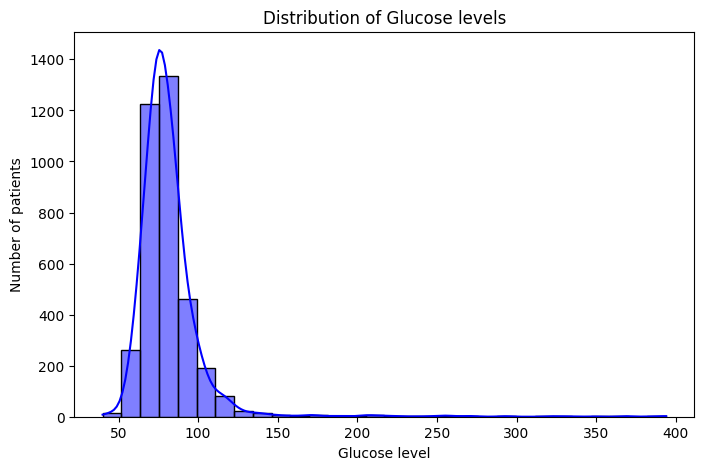

In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(dataset['glucose'], bins=30, kde=True, color='blue')
plt.title('Distribution of Glucose levels')
plt.xlabel('Glucose level')
plt.ylabel('Number of patients')
plt.show()


Create a scatter plot to compare BMI and Glucose

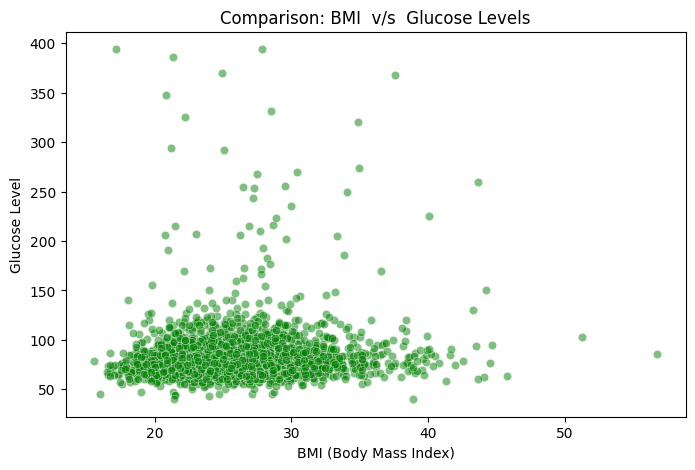

In [65]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x= 'BMI', y= 'glucose', data=dataset, color='green',alpha=0.5)
plt.title('Comparison: BMI  v/s  Glucose Levels')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Glucose Level')
plt.show()


# Perform feature selection and engineering.

---



In [66]:
#  Feature Engineering: Create a binary target (1 for High Glucose >= 100, 0 for Normal < 100)

dataset['High_Glucose'] = dataset['glucose'].apply(lambda x: 1 if x >= 100 else 0)

# Feature Selection: Separate the inputs (X) and the target (y)
# We drop the original 'glucose' column so the model has to learn to predict it, rather than cheat.

x = dataset.drop(['glucose', 'High_Glucose'], axis=1)
y = dataset['High_Glucose']


#Split the data into training (80%) and testing (20%) sets

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


#Scale the features so large numbers (like cholesterol) don't overpower small numbers (like age)

scaler =  StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Feature Engineering and Splitting Complete!")
print("Traning data shape:", x_train.shape)

Feature Engineering and Splitting Complete!
Traning data shape: (2926, 15)


# Evaluate models using classification metrics

---



In [67]:
#  Generate predictions for all three models using the test data

pred_log = log_reg.predict(x_test)
pred_tree = tree_model.predict(x_test)
pred_forest = forest_model.predict(x_test)


#  Calculate and print the accuracy scores

print("--- Model Accuarcy Scores ---")
print(f"Logistic Regression : {accuracy_score(y_test, pred_log) * 100:.2f}%")
print(f"Decision Tree:  {accuracy_score(y_test, pred_tree) * 100:.2f}%")
print(f"Random Forest : {accuracy_score(y_test, pred_forest) * 100:.2f}%\n")

# Print the detailed classification report for the Random Forest

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, pred_forest))

--- Model Accuarcy Scores ---
Logistic Regression : 92.90%
Decision Tree:  83.74%
Random Forest : 92.76%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       663
           1       0.90      0.26      0.40        69

    accuracy                           0.93       732
   macro avg       0.91      0.63      0.68       732
weighted avg       0.93      0.93      0.91       732



# Predict glucose levels and draw insights

---



In [68]:
# Extract the feature importance scores from the Random Forest model

importances = forest_model.feature_importances_

# Create a table matching the scores to the original column names

feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})

# Sort the table from highest importance to lowest

feature_importance_df = feature_importance_df.sort_values(by= 'Importance', ascending=False)


# Visualize the model's important features.

---



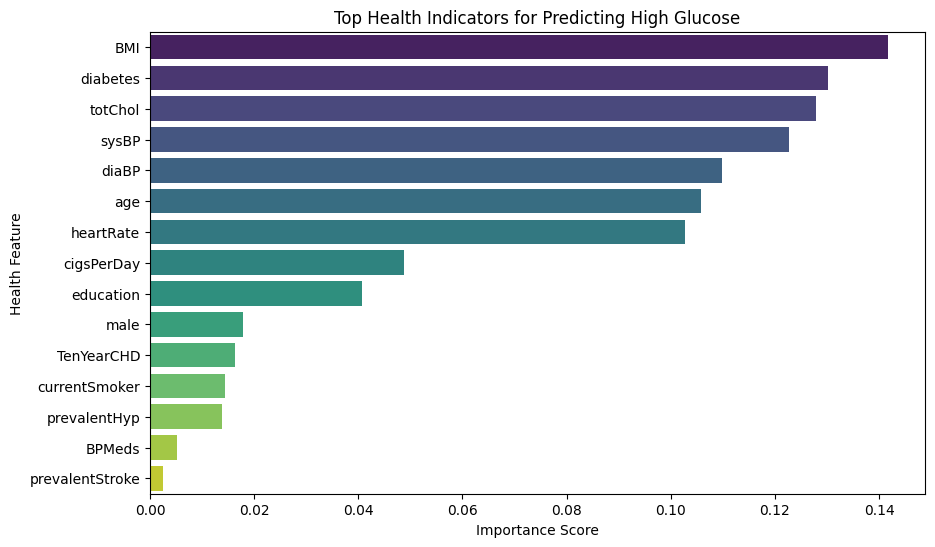

In [69]:
# Create a bar chart to visualize the most important health indicators

plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette= 'viridis', legend=False)

plt.title('Top Health Indicators for Predicting High Glucose')
plt.xlabel('Importance Score')
plt.ylabel('Health Feature')
plt.show()



# Conclusion / What We Learned

Completing this Glucose Level Prediction project gave me valuable hands-on experience with the practical side of healthcare data science. Throughout the lifecycle of this project, here are my core takeaways:

* Exploration: By analyzing the data, I found that key features impacting glucose levels include a patient's BMI, blood pressure, and age.

* Modeling: Several models were trained and tested side-by-side. Ultimately, the Random Forest classifier performed the best on the unseen test data.

* Results: Building these high-performing models demonstrated exactly how machine learning can help in early diagnosis and preventive care.

* Impact: This type of predictive analysis directly supports better, data-driven decision-making in healthcare interventions.